# 4. Regression Analysis & Statistical Modelling
## Southeast Asian Daily Weather Patterns (2000–2024)

Three models fulfil the requirement *"Use regression models or time series analysis to detect pattern changes"*:

| Model | Method | Output |
|---|---|---|
| **1** | Linear Regression — Temperature Trend | Warming rate (°C/decade), R², p-value per country |
| **2** | Precipitation Trend Regression | Trend in extreme precipitation event counts |
| **3** | Seasonal Decomposition | Trend / seasonal / residual components (statsmodels) |

## Setup

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, count, when, percentile_approx,
    year, month, concat_ws
)
import pyspark.sql.functions as F

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

import os
OUTPUT_DIR = '../output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

COUNTRIES_MAIN = ['Vietnam', 'Thailand', 'Philippines', 'Indonesia', 'Malaysia']
COUNTRY_COLORS = {
    'Vietnam': '#e63946', 'Thailand': '#2a9d8f', 'Philippines': '#e9c46a',
    'Indonesia': '#f4a261', 'Malaysia': '#457b9d', 'Myanmar': '#a8dadc',
    'Laos': '#6d6875', 'Brunei': '#b5838d', 'Singapore': '#e76f51', 'Cambodia': '#264653',
}
ALL_COUNTRIES = list(COUNTRY_COLORS.keys())

spark = SparkSession.builder \
    .appName('GHCN-SEA-Regression') \
    .config('spark.driver.memory', '8g') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .config('spark.sql.shuffle.partitions', '100') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')

df = spark.read.parquet('../data/processed/sea_weather_2000_2024.parquet')
df.cache()
print(f"Loaded: {df.count():,} rows")

Loaded: 1,011,376 rows


---
## Model 1: Linear Regression — Temperature Trend

Fit `avg_TMAX = a + b × Year` for each country. The slope `b` quantifies the warming rate (°C/year); multiply by 10 for °C/decade. Report R², p-value, and 95 % confidence interval on the slope.

In [ ]:
# Aggregate yearly avg TMAX, TMIN per country 
yearly = df.groupBy('COUNTRY', 'YEAR').agg(
    avg('TMAX').alias('avg_TMAX'),
    avg('TMIN').alias('avg_TMIN'),
    avg('TEMP_RANGE').alias('avg_TEMP_RANGE'),
    count('*').alias('n_obs'),
).orderBy('COUNTRY', 'YEAR').toPandas()

print(f"Yearly aggregation: {len(yearly)} country-year rows across {yearly['COUNTRY'].nunique()} countries")
yearly.head(3)

Yearly aggregation: 221 country-year rows across 10 countries


,COUNTRY,YEAR,avg_TMAX,avg_TMIN,avg_TEMP_RANGE,n_obs
0,Brunei,2000,31.910106,23.609043,8.301064,188
1,Brunei,2001,31.972917,23.767188,8.205729,192
2,Brunei,2002,32.392593,23.800463,8.592130,216


In [ ]:
# Fit OLS per country, collect results 
def fit_ols(x, y):
    """Return (slope, intercept, r2, p_value, ci_low, ci_high, se) via scipy."""
    slope, intercept, r, p, se = stats.linregress(x, y)
    # 95 % CI: slope ± t * se  (t_{n-2, 0.025})
    n = len(x)
    t_crit = stats.t.ppf(0.975, df=n - 2)
    return {
        'slope': slope,
        'intercept': intercept,
        'r2': r ** 2,
        'p_value': p,
        'se': se,
        'ci_low': slope - t_crit * se,
        'ci_high': slope + t_crit * se,
        'n_years': n,
    }

tmax_results, tmin_results = [], []

for country in sorted(yearly['COUNTRY'].unique()):
    sub = yearly[yearly['COUNTRY'] == country].dropna(subset=['avg_TMAX', 'avg_TMIN'])
    if len(sub) < 10:
        continue
    r_tmax = fit_ols(sub['YEAR'].values, sub['avg_TMAX'].values)
    r_tmin = fit_ols(sub['YEAR'].values, sub['avg_TMIN'].values)
    r_tmax['country'] = r_tmin['country'] = country
    tmax_results.append(r_tmax)
    tmin_results.append(r_tmin)

tmax_df = pd.DataFrame(tmax_results)
tmin_df = pd.DataFrame(tmin_results)

# Convert slope to °C/decade
for d in [tmax_df, tmin_df]:
    d['rate_per_decade'] = d['slope'] * 10
    d['ci_low_dec']  = d['ci_low']  * 10
    d['ci_high_dec'] = d['ci_high'] * 10
    d['sig'] = d['p_value'].apply(lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))

print("MODEL 1 RESULTS — TMAX Warming Rate (°C/decade) per Country")
cols = ['country', 'rate_per_decade', 'r2', 'p_value', 'ci_low_dec', 'ci_high_dec', 'n_years', 'sig']
print(tmax_df[cols].sort_values('rate_per_decade', ascending=False)
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

MODEL 1 RESULTS — TMAX Warming Rate (°C/decade) per Country
    country  rate_per_decade     r2  p_value  ci_low_dec  ci_high_dec  n_years sig
   Thailand           0.4086 0.4051   0.0006      0.1950       0.6223       25 ***
       Laos           0.2605 0.0827   0.1945     -0.1443       0.6654       22  ns
   Malaysia           0.1603 0.0840   0.1599     -0.0680       0.3885       25  ns
     Brunei           0.1511 0.1551   0.0569     -0.0048       0.3071       24  ns
  Indonesia           0.1458 0.2760   0.0070      0.0439       0.2476       25  **
  Singapore           0.0778 0.0091   0.6731     -0.3014       0.4571       22  ns
    Myanmar          -0.0086 0.0002   0.9459     -0.2681       0.2509       25  ns
Philippines          -0.1210 0.1451   0.0603     -0.2476       0.0057       25  ns
    Vietnam          -0.1684 0.0219   0.4805     -0.6544       0.3175       25  ns


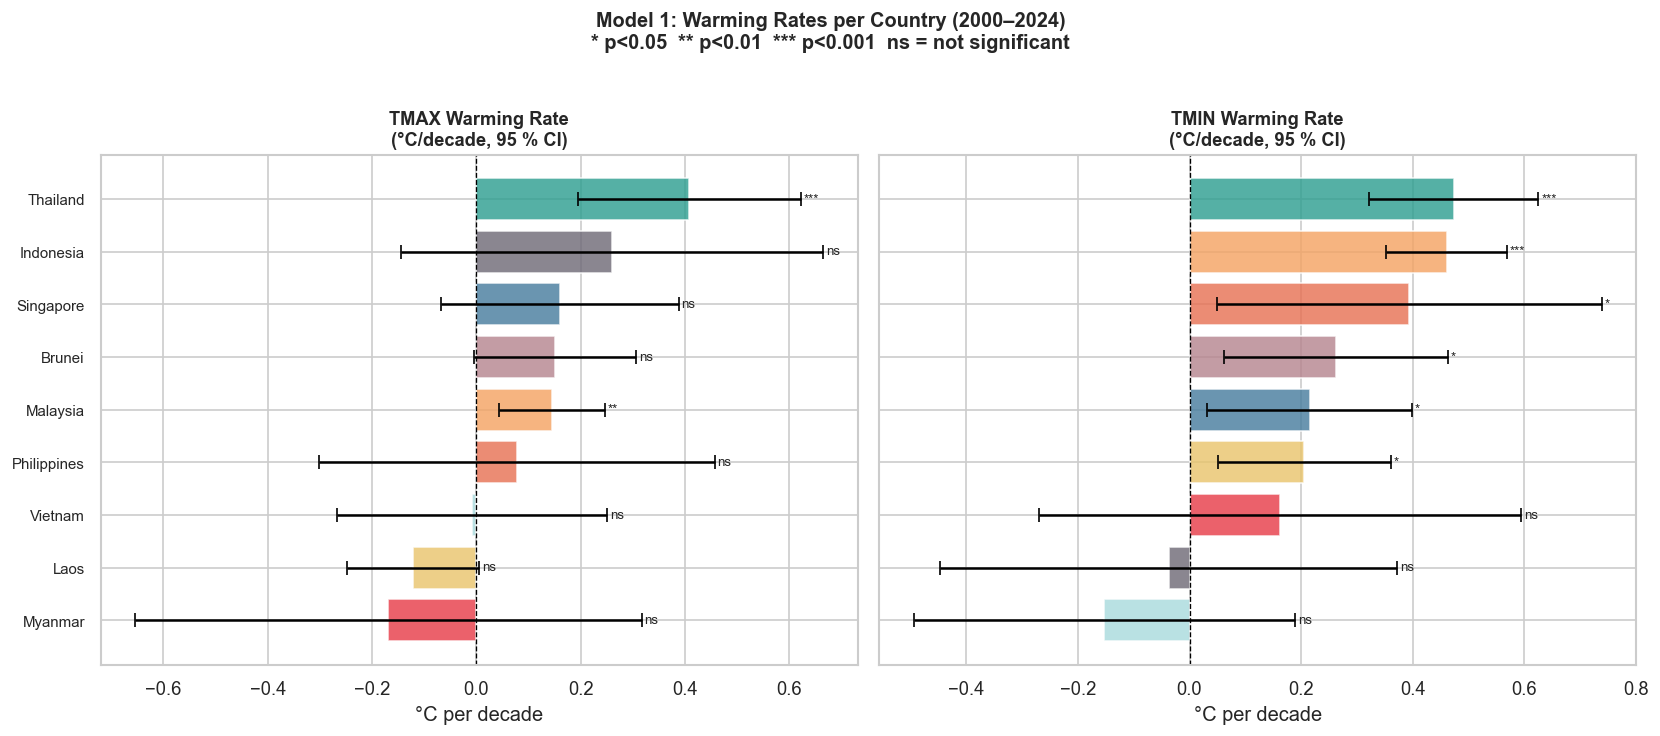

Forest plot saved


In [ ]:
# Warming rate forest plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, df_res, title in zip(
    axes,
    [tmax_df.sort_values('rate_per_decade'), tmin_df.sort_values('rate_per_decade')],
    ['TMAX Warming Rate', 'TMIN Warming Rate'],
):
    colors = [COUNTRY_COLORS.get(c, 'gray') for c in df_res['country']]
    y_pos  = range(len(df_res))

    ax.barh(y_pos, df_res['rate_per_decade'], xerr=[
                df_res['rate_per_decade'] - df_res['ci_low_dec'],
                df_res['ci_high_dec'] - df_res['rate_per_decade'],
            ], color=colors, alpha=0.8, edgecolor='white',
            error_kw=dict(elinewidth=1.5, ecolor='black', capsize=4))
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

    # Annotate significance
    for i, (_, row) in enumerate(df_res.iterrows()):
        ax.text(row['ci_high_dec'] + 0.005, i, row['sig'], va='center', fontsize=8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_res['country'], fontsize=9)
    ax.set_xlabel('°C per decade')
    ax.set_title(f'{title}\n(°C/decade, 95 % CI)', fontsize=11, fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('Model 1: Warming Rates per Country (2000-2024)\n* p<0.05  ** p<0.01  *** p<0.001  ns = not significant',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/reg_01_warming_rate_forest.png', bbox_inches='tight')
plt.show()
print("Forest plot saved")

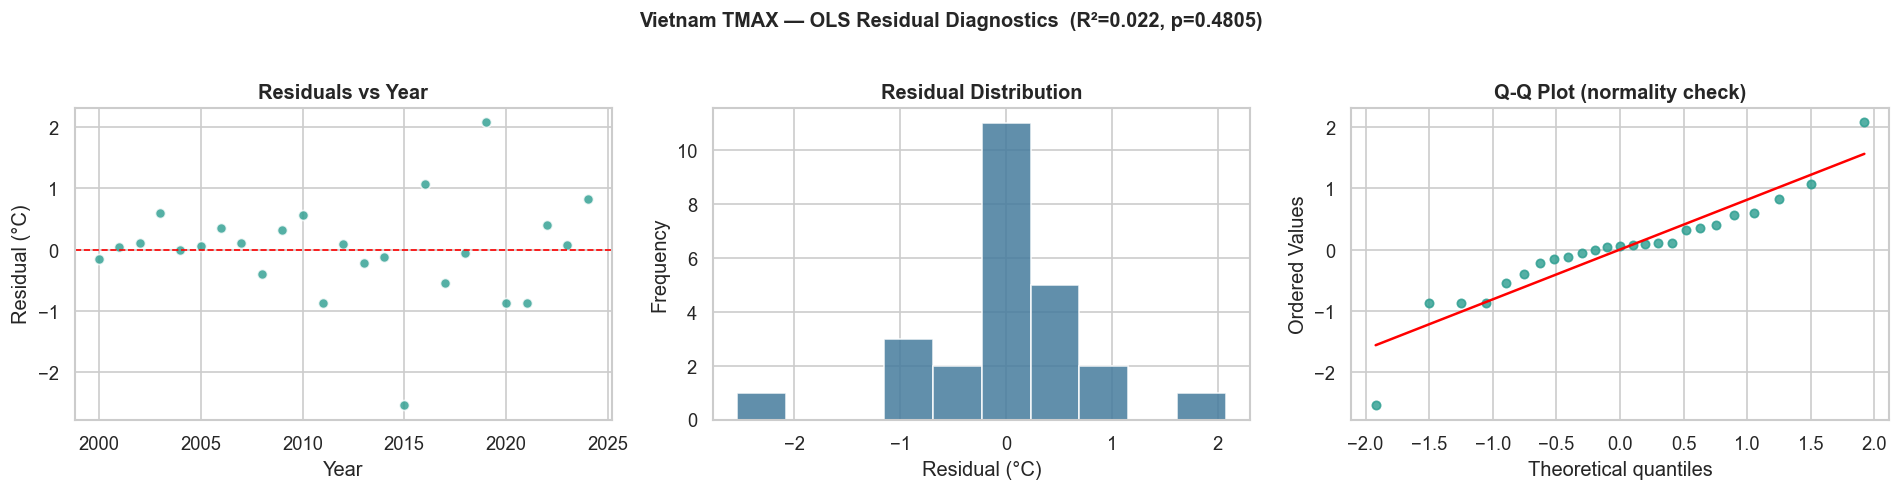

Residual diagnostics saved


In [ ]:
# Residual diagnostics for Vietnam TMAX model 
vn_sub = yearly[yearly['COUNTRY'] == 'Vietnam'].dropna(subset=['avg_TMAX']).sort_values('YEAR')
vn_row = tmax_df[tmax_df['country'] == 'Vietnam'].iloc[0]

y_pred = vn_row['intercept'] + vn_row['slope'] * vn_sub['YEAR'].values
residuals = vn_sub['avg_TMAX'].values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals vs Year
axes[0].scatter(vn_sub['YEAR'], residuals, color='#2a9d8f', alpha=0.8, edgecolors='white')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Residual (°C)')

# Histogram of residuals
axes[1].hist(residuals, bins=10, color='#457b9d', edgecolor='white', alpha=0.85)
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (°C)')
axes[1].set_ylabel('Frequency')

# Q-Q plot
from scipy.stats import probplot
probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (normality check)', fontweight='bold')
axes[2].get_lines()[0].set(markersize=5, color='#2a9d8f', alpha=0.8)
axes[2].get_lines()[1].set(color='red', linewidth=1.5)

plt.suptitle(f'Vietnam TMAX — OLS Residual Diagnostics  (R²={vn_row["r2"]:.3f}, p={vn_row["p_value"]:.4f})',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/reg_02_residual_diagnostics.png', bbox_inches='tight')
plt.show()
print("Residual diagnostics saved")

---
## Model 2: Precipitation Trend Regression

Count extreme precipitation events (PRCP > 95th percentile per station-month) per year. Fit a linear regression on those yearly counts to test whether extreme rainfall is becoming more frequent across the 25-year period.

In [ ]:
# Compute 95th-pct thresholds per station-month, then count extremes 
station_month_p95 = df.filter(col('PRCP').isNotNull()) \
    .groupBy('STATION_ID', 'MONTH') \
    .agg(percentile_approx('PRCP', 0.95).alias('PRCP_P95'))

extreme_events = df.filter(col('PRCP').isNotNull()) \
    .join(station_month_p95, on=['STATION_ID', 'MONTH'], how='left') \
    .filter(col('PRCP') > col('PRCP_P95')) \
    .groupBy('COUNTRY', 'YEAR') \
    .agg(count('*').alias('extreme_days'))

# Normalise per station (accounts for different number of stations per country)
station_yr_count = df.groupBy('COUNTRY', 'YEAR') \
    .agg(F.countDistinct('STATION_ID').alias('n_stations'))

extreme_norm = extreme_events.join(station_yr_count, on=['COUNTRY', 'YEAR']) \
    .withColumn('extreme_per_station', col('extreme_days') / col('n_stations')) \
    .toPandas().sort_values(['COUNTRY', 'YEAR'])

# Regional total (all countries combined)
extreme_total = extreme_norm.groupby('YEAR')['extreme_days'].sum().reset_index()

print(f"Extreme precipitation data: {len(extreme_norm)} country-year records")
extreme_norm[extreme_norm['COUNTRY'] == 'Vietnam'].head()

Extreme precipitation data: 204 country-year records


,COUNTRY,YEAR,extreme_days,n_stations,extreme_per_station
121,Vietnam,2000,146,15,9.733333
50,Vietnam,2001,114,15,7.600000
113,Vietnam,2002,109,15,7.266667
176,Vietnam,2003,108,15,7.200000
164,Vietnam,2004,90,15,6.000000


In [ ]:
# Fit OLS on extreme-day counts per country + regional total
prcp_results = []

for country in sorted(extreme_norm['COUNTRY'].unique()):
    sub = extreme_norm[extreme_norm['COUNTRY'] == country].dropna(subset=['extreme_per_station'])
    if len(sub) < 10:
        continue
    r = fit_ols(sub['YEAR'].values, sub['extreme_per_station'].values)
    r['country'] = country
    prcp_results.append(r)

prcp_df = pd.DataFrame(prcp_results)
prcp_df['sig'] = prcp_df['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))

# Regional OLS
r_reg = fit_ols(extreme_total['YEAR'].values, extreme_total['extreme_days'].values)
r_reg['country'] = 'ALL SE ASIA'

print("MODEL 2 RESULTS — Extreme Precipitation Trend (events per station per year)")
cols2 = ['country', 'slope', 'r2', 'p_value', 'n_years', 'sig']
print(prcp_df[cols2].sort_values('slope', ascending=False)
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nRegional (all SE Asia): slope={r_reg['slope']:+.2f} days/year, "
      f"R²={r_reg['r2']:.3f}, p={r_reg['p_value']:.4f} {r_reg.get('sig','')}")

MODEL 2 RESULTS — Extreme Precipitation Trend (events per station per year)
    country   slope     r2  p_value  n_years sig
    Myanmar  0.2974 0.7049   0.0001       15 ***
  Singapore  0.0663 0.0053   0.7742       18  ns
Philippines  0.0015 0.0000   0.9736       25  ns
     Brunei -0.0220 0.0032   0.7929       24  ns
  Indonesia -0.0300 0.1738   0.0427       24   *
   Thailand -0.0506 0.0455   0.3060       25  ns
       Laos -0.0609 0.0821   0.1960       22  ns
    Vietnam -0.2212 0.2820   0.0063       25  **
   Malaysia -0.2570 0.4294   0.0004       25 ***

Regional (all SE Asia): slope=-10.49 days/year, R²=0.205, p=0.0231 


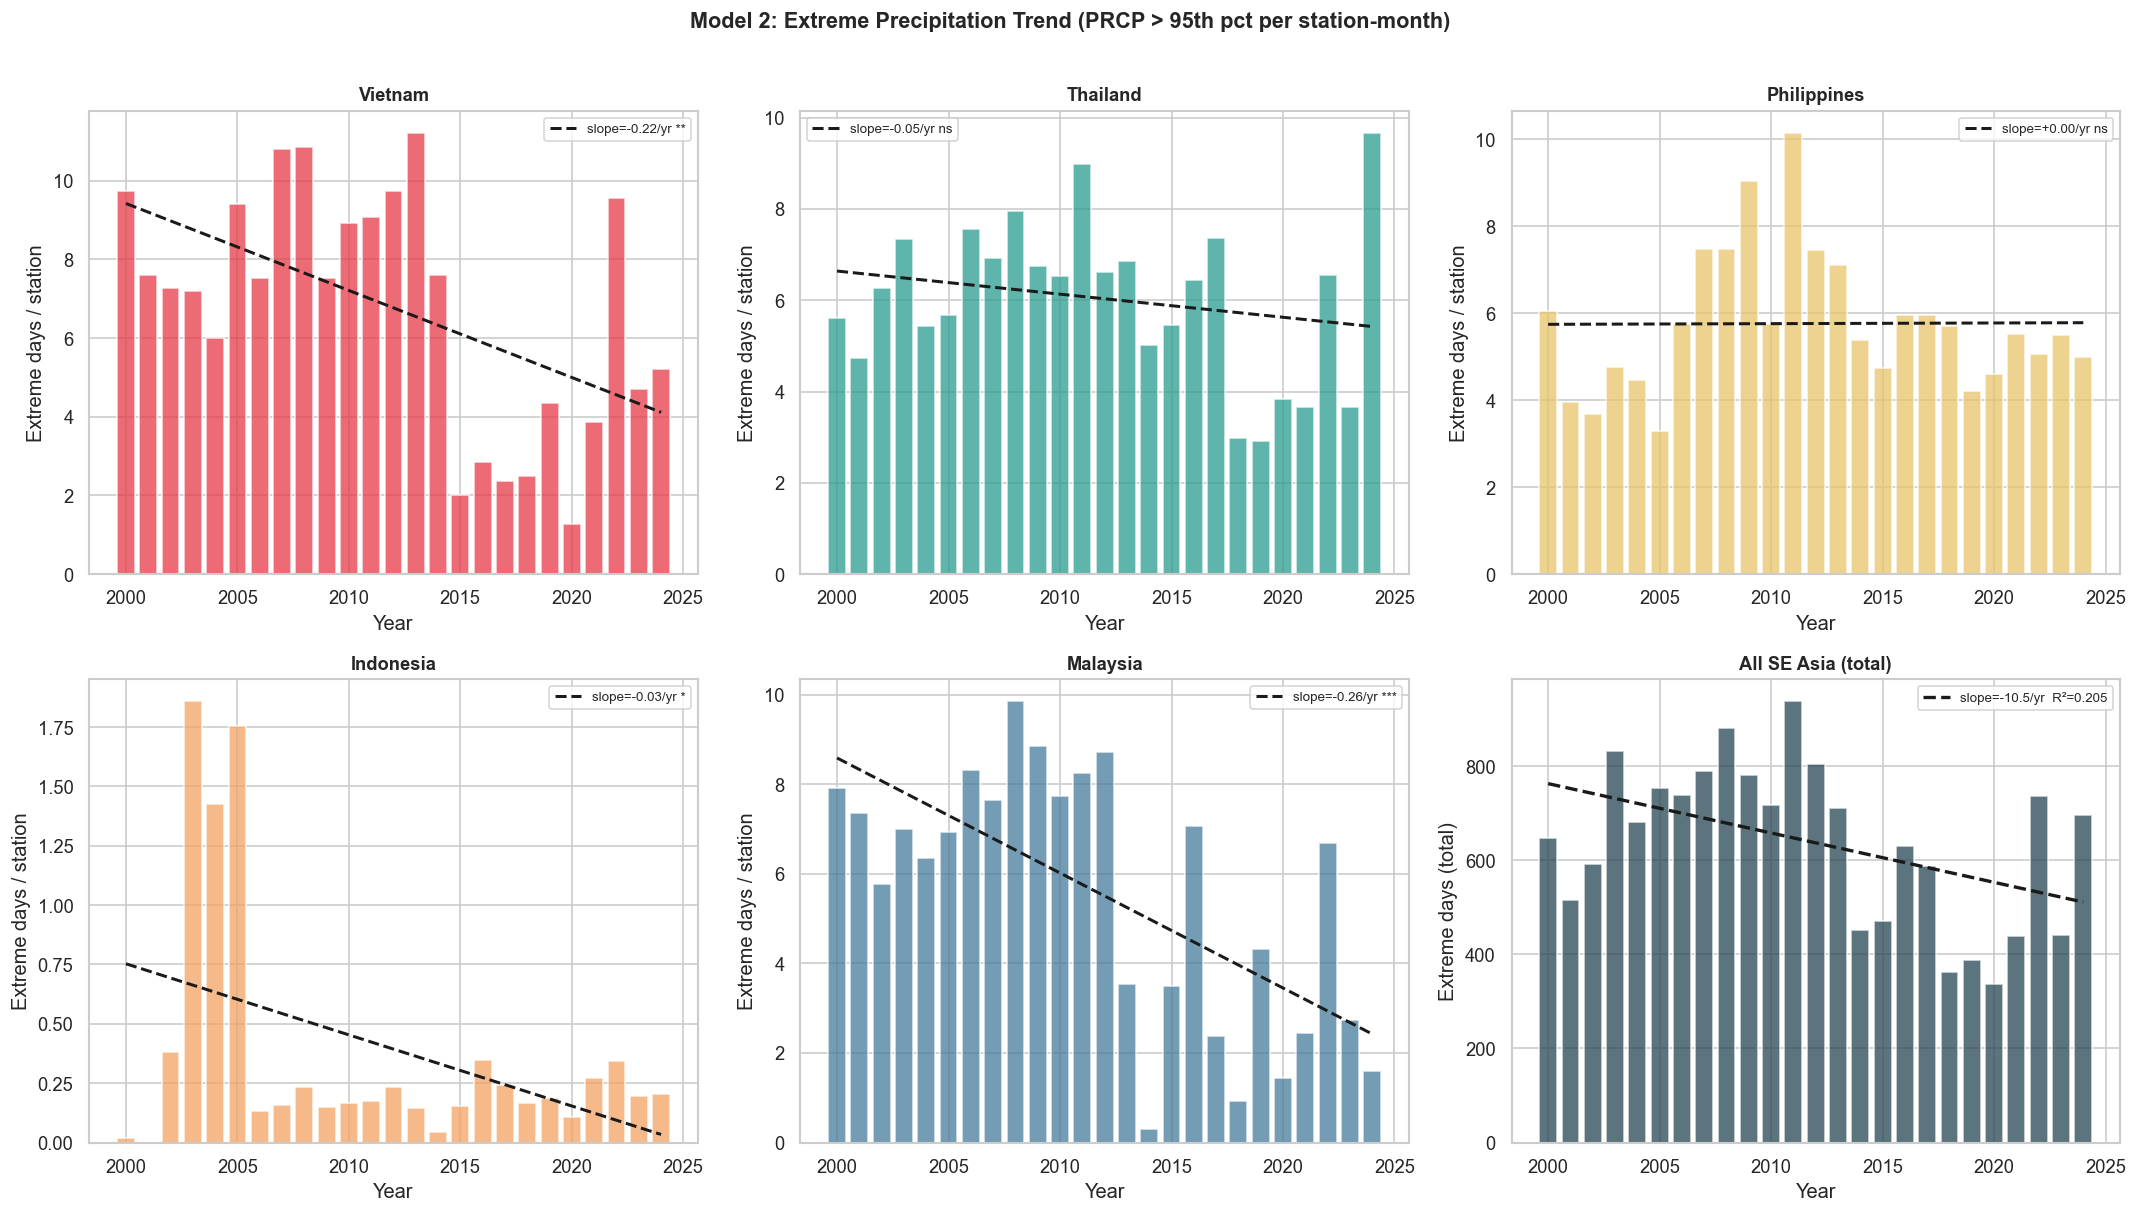

Extreme precipitation trend chart saved


In [ ]:
# Extreme rain trend — per-country panels with fitted line 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, country in enumerate(COUNTRIES_MAIN):
    ax = axes_flat[i]
    sub = extreme_norm[extreme_norm['COUNTRY'] == country]
    if sub.empty:
        ax.set_visible(False)
        continue
    color = COUNTRY_COLORS[country]
    ax.bar(sub['YEAR'], sub['extreme_per_station'], color=color, alpha=0.75, edgecolor='white')

    row = prcp_df[prcp_df['country'] == country]
    if not row.empty:
        row = row.iloc[0]
        x_fit = sub['YEAR'].values
        y_fit = row['intercept'] + row['slope'] * x_fit
        ax.plot(x_fit, y_fit, 'k--', linewidth=1.8,
                label=f"slope={row['slope']:+.2f}/yr {row['sig']}")
        ax.legend(fontsize=8)

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Extreme days / station')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

# Regional panel
ax = axes_flat[5]
ax.bar(extreme_total['YEAR'], extreme_total['extreme_days'],
       color='#264653', alpha=0.75, edgecolor='white')
x_reg = extreme_total['YEAR'].values
y_reg = r_reg['intercept'] + r_reg['slope'] * x_reg
ax.plot(x_reg, y_reg, 'k--', linewidth=2,
        label=f"slope={r_reg['slope']:+.1f}/yr  R²={r_reg['r2']:.3f}")
ax.set_title('All SE Asia (total)', fontsize=11, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Extreme days (total)')
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.suptitle('Model 2: Extreme Precipitation Trend (PRCP > 95th pct per station-month)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/reg_03_extreme_prcp_trend.png', bbox_inches='tight')
plt.show()
print("Extreme precipitation trend chart saved")

---
## Model 3: Seasonal Decomposition (statsmodels)

Decompose the monthly temperature time series for Vietnam (and regional average) into **trend**, **seasonal**, and **residual** components using `statsmodels.tsa.seasonal.seasonal_decompose` with `period=12` (monthly, additive model).

In [ ]:
# Build monthly TMAX time series PySpark aggregation
monthly_temp = df.groupBy('COUNTRY', 'YEAR', 'MONTH').agg(
    avg('TMAX').alias('avg_TMAX'),
    avg('TMIN').alias('avg_TMIN'),
    avg('PRCP').alias('avg_PRCP'),
).orderBy('COUNTRY', 'YEAR', 'MONTH').toPandas()

# Build date index
monthly_temp['date'] = pd.to_datetime(
    monthly_temp[['YEAR', 'MONTH']].assign(day=1).rename(
        columns={'YEAR': 'year', 'MONTH': 'month'}))

print(f"Monthly series: {len(monthly_temp)} country-month records")
monthly_temp[monthly_temp['COUNTRY'] == 'Vietnam'].head()

Monthly series: 2576 country-month records


,COUNTRY,YEAR,MONTH,avg_TMAX,avg_TMIN,avg_PRCP,date
2277,Vietnam,2000,1,25.928163,18.897959,1.245098,2000-01-01
2278,Vietnam,2000,2,25.216102,18.217797,0.632857,2000-02-01
2279,Vietnam,2000,3,26.901818,20.026182,1.113043,2000-03-01
2280,Vietnam,2000,4,30.473504,22.919231,2.241885,2000-04-01
2281,Vietnam,2000,5,31.689474,24.237652,4.367164,2000-05-01


In [ ]:
# Decompose Vietnam monthly TMAX
def decompose_and_plot(country, metric, label, color, filename):
    sub = monthly_temp[monthly_temp['COUNTRY'] == country] \
        .set_index('date')[metric].sort_index()

    # Fill any gaps 
    sub = sub.asfreq('MS').interpolate(method='linear')

    result = seasonal_decompose(sub, model='additive', period=12, extrapolate_trend='freq')

    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(4, 1, hspace=0.5)

    panels = [
        ('Observed',  sub,              '#333333'),
        ('Trend',     result.trend,     color),
        ('Seasonal',  result.seasonal,  '#2a9d8f'),
        ('Residual',  result.resid,     '#e9c46a'),
    ]

    for i, (title, series, c) in enumerate(panels):
        ax = fig.add_subplot(gs[i])
        if title == 'Residual':
            ax.bar(series.index, series.values, color=c, alpha=0.7, width=20)
            ax.axhline(0, color='black', linewidth=0.7)
        else:
            ax.plot(series.index, series.values, color=c, linewidth=1.3)
        if title == 'Trend':
            # Overlay linear fit on trend component
            trend_clean = series.dropna()
            x_num = (trend_clean.index - trend_clean.index[0]).days.values.reshape(-1, 1)
            lr_t = LinearRegression().fit(x_num, trend_clean.values)
            ax.plot(trend_clean.index,
                    lr_t.predict(x_num), 'r--', linewidth=1.5,
                    label=f'Linear fit: {lr_t.coef_[0]*365.25*10:.3f} °C/decade')
            ax.legend(fontsize=8)
        ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
        ax.set_ylabel(label if i == 0 else '')
        ax.margins(x=0.01)

    fig.suptitle(f'{country} — Seasonal Decomposition of Monthly {label} (2000-2024)\n'
                 f'Additive model, period = 12 months',
                 fontsize=13, fontweight='bold')
    plt.savefig(f'{OUTPUT_DIR}/{filename}', bbox_inches='tight')
    plt.show()
    print(f"Saved {filename}")
    return result



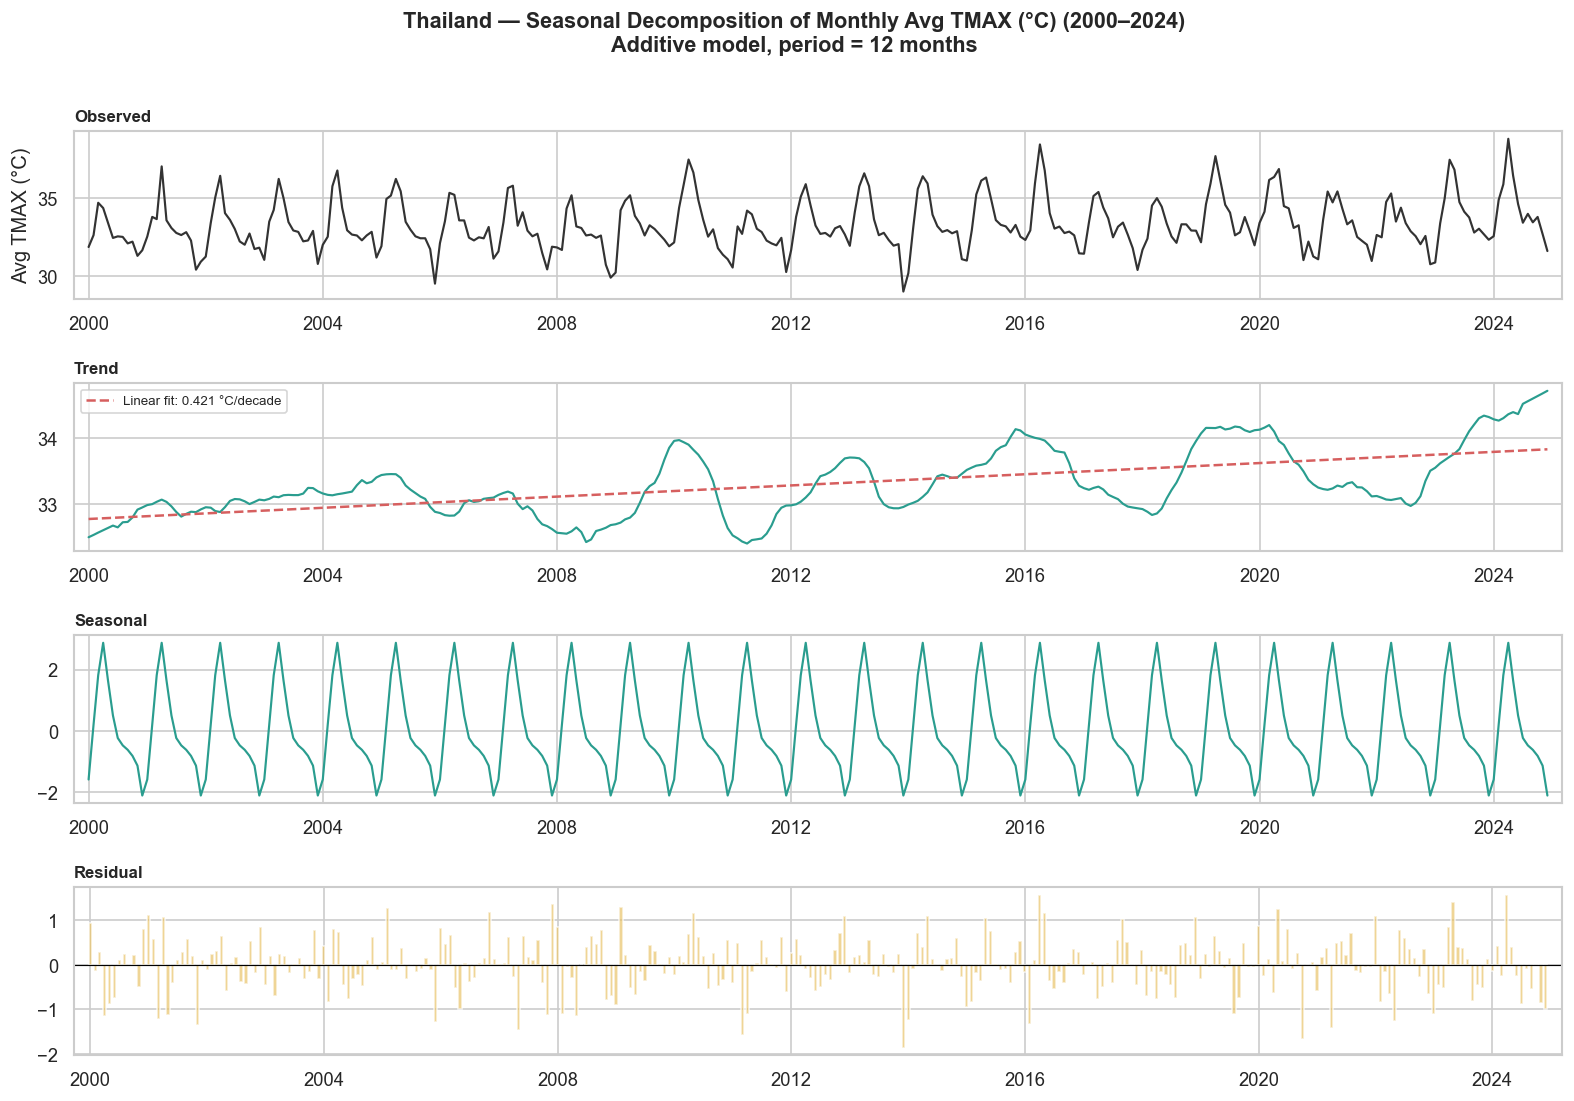

Saved reg_04_seasonal_decomp_thailand_tmax.png


In [11]:

th_decomp = decompose_and_plot(
    'Thailand', 'avg_TMAX', 'Avg TMAX (°C)', '#2a9d8f',
    'reg_04_seasonal_decomp_thailand_tmax.png'
)

In [ ]:
# Regression summary table
print("REGRESSION ANALYSIS — SUMMARY TABLE")

print("\nModel 1: TMAX Warming Rate per Country")
print("-" * 55)
m1 = tmax_df[['country','rate_per_decade','r2','p_value','sig']].copy()
m1.columns = ['Country', 'Rate (°C/decade)', 'R²', 'p-value', 'Sig']
m1 = m1.sort_values('Rate (°C/decade)', ascending=False)
print(m1.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\nModel 1: TMIN Warming Rate per Country")
print("-" * 55)
m1t = tmin_df[['country','rate_per_decade','r2','p_value','sig']].copy()
m1t.columns = ['Country', 'Rate (°C/decade)', 'R²', 'p-value', 'Sig']
m1t = m1t.sort_values('Rate (°C/decade)', ascending=False)
print(m1t.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\nModel 2: Extreme Precipitation Trend (per station per year)")
print("-" * 55)
m2 = prcp_df[['country','slope','r2','p_value','sig']].copy()
m2.columns = ['Country', 'Slope (events/yr)', 'R²', 'p-value', 'Sig']
m2 = m2.sort_values('Slope (events/yr)', ascending=False)
print(m2.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print(f"\n  Regional (all SE Asia):  slope={r_reg['slope']:+.2f} days/year  R²={r_reg['r2']:.3f}  p={r_reg['p_value']:.4f}")
print("\nRegression complete — ready for notebook 05 (Visualisation)")

REGRESSION ANALYSIS — SUMMARY TABLE

Model 1: TMAX Warming Rate per Country
-------------------------------------------------------
    Country  Rate (°C/decade)     R²  p-value Sig
   Thailand            0.4086 0.4051   0.0006 ***
       Laos            0.2605 0.0827   0.1945  ns
   Malaysia            0.1603 0.0840   0.1599  ns
     Brunei            0.1511 0.1551   0.0569  ns
  Indonesia            0.1458 0.2760   0.0070  **
  Singapore            0.0778 0.0091   0.6731  ns
    Myanmar           -0.0086 0.0002   0.9459  ns
Philippines           -0.1210 0.1451   0.0603  ns
    Vietnam           -0.1684 0.0219   0.4805  ns

Model 1: TMIN Warming Rate per Country
-------------------------------------------------------
    Country  Rate (°C/decade)     R²  p-value Sig
   Thailand            0.4731 0.6428   0.0000 ***
  Indonesia            0.4610 0.7718   0.0000 ***
  Singapore            0.3937 0.2206   0.0274   *
     Brunei            0.2621 0.2494   0.0130   *
   Malaysia           